In [ ]:
from pathlib import Path
import gc
import json
import warnings

import numpy as np
import pandas as pd
import xgboost as xgb
from scipy.stats import ConstantInputWarning, spearmanr
from sklearn.metrics import mean_squared_error, r2_score
from tqdm import tqdm

BASE_DIR = Path.cwd()
SS_TEST_PATH = BASE_DIR
CONFIG_PATH = BASE_DIR / 'FINAL_cascade_config_v3.json'
MODEL_DIR = BASE_DIR / 'cascade_training_v3_gpu_fast' / 'models'
OUTPUT_DIR = BASE_DIR / 'test_inference_v3_gpu_fast'
OUTPUT_DIR.mkdir(exist_ok=True)

TEST_FOLDS = [1, 2, 3, 4, 5, 10]

warnings.filterwarnings('ignore', category=ConstantInputWarning)
warnings.filterwarnings('ignore', message='.*highly fragmented.*')

with open(CONFIG_PATH, 'r', encoding='utf-8') as f:
    config = json.load(f)

stages = config['stages']
features_map = config['features']
ordered_stages = sorted(stages.keys(), key=lambda s: int(s.split('_')[-1]))

print('Notebook initialized')
print('Stages:', ordered_stages)
print('Model dir:', MODEL_DIR)


Notebook initialized
Stages: ['stage_1', 'stage_2', 'stage_3', 'stage_4', 'stage_5', 'stage_6', 'stage_7']
Model dir: /home/amismailov/project/cascade_training_v3_gpu_fast/models


In [6]:
X_ss_test_raw = {}
y_ss_test_raw = {}

for k in TEST_FOLDS:
    x_file = SS_TEST_PATH / f'TEST/X_K{k}.parquet'
    y_file = SS_TEST_PATH / f'TEST/Y_K{k}.parquet'

    X_ss_test_raw[k] = pd.read_parquet(x_file)
    y_ss_test_raw[k] = pd.read_parquet(y_file)

    assert (X_ss_test_raw[k].columns == y_ss_test_raw[k].columns).all(), f'Mismatch in cells for K{k}!'

X_ss_test_base = {k: df.T.copy() for k, df in X_ss_test_raw.items()}
y_ss_test_casc = {k: df.T.copy() for k, df in y_ss_test_raw.items()}
X_ss_test_work = {k: df.copy() for k, df in X_ss_test_base.items()}

for k in TEST_FOLDS:
    assert X_ss_test_work[k].index.equals(y_ss_test_casc[k].index)
    print(f'K{k}: X={X_ss_test_work[k].shape}, y={y_ss_test_casc[k].shape}')


K1: X=(2000, 17392), y=(2000, 236)
K2: X=(300, 17392), y=(300, 236)
K3: X=(200, 17392), y=(200, 236)
K4: X=(120, 17392), y=(120, 236)
K5: X=(60, 17392), y=(60, 236)
K10: X=(40, 17392), y=(40, 236)


In [7]:
detailed_metrics = []
predictions_by_fold = {k: pd.DataFrame(index=X_ss_test_work[k].index) for k in TEST_FOLDS}

def get_metrics(y_true, y_pred):
    r2 = float(r2_score(y_true, y_pred))
    if np.std(y_true) == 0 or np.std(y_pred) == 0:
        rho, pvalue = np.nan, np.nan
    else:
        rho, pvalue = spearmanr(y_true, y_pred)
    mse = float(mean_squared_error(y_true, y_pred))
    rho = float(rho) if not np.isnan(rho) else np.nan
    pvalue = float(pvalue) if not np.isnan(pvalue) else np.nan
    return r2, rho, pvalue, mse

def resolve_feature_matrix(feature_list, X_work):
    available = [f for f in feature_list if f in X_work.columns]
    missing = [f for f in feature_list if f not in X_work.columns]
    if not available:
        raise ValueError('No available features for inference')
    return X_work[available], available, missing

print('Helper functions are ready')


Helper functions are ready


In [8]:
# Honest staged inference.
# Predicted targets are appended only after the whole stage finishes,
# so stage_k never sees predictions from the same stage.

for stage_name in ordered_stages:
    mirnas = stages[stage_name]
    print(f'\n[INFERENCE] {stage_name.upper()} | targets={len(mirnas)}')

    stage_predictions = {k: {} for k in TEST_FOLDS}

    for mir in tqdm(mirnas, desc=f'Predicting {stage_name}'):
        model_path = MODEL_DIR / stage_name / f'{mir}.json'
        if not model_path.exists():
            print(f'Skip {mir}: model not found at {model_path}')
            continue

        model = xgb.XGBRegressor()
        model.load_model(model_path)
        feats = features_map[mir]

        for k in TEST_FOLDS:
            X_input, feats_used, feats_missing = resolve_feature_matrix(feats, X_ss_test_work[k])
            preds = model.predict(X_input)
            stage_predictions[k][mir] = preds
            predictions_by_fold[k][mir] = preds

            y_true = y_ss_test_casc[k][mir]
            r2, rho, pvalue, mse = get_metrics(y_true, preds)

            detailed_metrics.append({
                'miRNA': mir,
                'stage': stage_name,
                'fold': f'K{k}',
                'n_features_used': len(feats_used),
                'n_missing_features': len(feats_missing),
                'R2': r2,
                'Spearman': rho,
                'Spearman_pvalue': pvalue,
                'MSE': mse,
            })

        del model
        gc.collect()

    for k in TEST_FOLDS:
        if stage_predictions[k]:
            stage_pred_df = pd.DataFrame(stage_predictions[k], index=X_ss_test_work[k].index)
            X_ss_test_work[k] = pd.concat([X_ss_test_work[k], stage_pred_df], axis=1)

metrics_df = pd.DataFrame(detailed_metrics)
metrics_df.to_csv(OUTPUT_DIR / 'detailed_metrics.csv', index=False)

summary_df = (
    metrics_df.groupby(['stage', 'miRNA'], as_index=False)
    .agg({
        'R2': 'mean',
        'Spearman': 'mean',
        'MSE': 'mean',
        'n_features_used': 'mean',
        'n_missing_features': 'mean',
    })
)
summary_df.to_csv(OUTPUT_DIR / 'summary_metrics.csv', index=False)

for k in TEST_FOLDS:
    predictions_by_fold[k].to_parquet(OUTPUT_DIR / f'predictions_K{k}.parquet')

print('Inference finished')
print(f"Detailed metrics: {OUTPUT_DIR / 'detailed_metrics.csv'}")
print(f"Summary metrics:  {OUTPUT_DIR / 'summary_metrics.csv'}")



[INFERENCE] STAGE_1 | targets=55


Predicting stage_1: 100%|██████████| 55/55 [00:26<00:00,  2.04it/s]



[INFERENCE] STAGE_2 | targets=39


Predicting stage_2: 100%|██████████| 39/39 [00:16<00:00,  2.34it/s]



[INFERENCE] STAGE_3 | targets=2


...


[INFERENCE] STAGE_6 | targets=6


Predicting stage_6: 100%|██████████| 6/6 [00:02<00:00,  2.29it/s]



[INFERENCE] STAGE_7 | targets=100


Predicting stage_7: 100%|██████████| 100/100 [00:41<00:00,  2.39it/s]


Inference finished
Detailed metrics: /home/amismailov/project/test_inference_v3_gpu_fast/detailed_metrics.csv
Summary metrics:  /home/amismailov/project/test_inference_v3_gpu_fast/summary_metrics.csv


/tmp/ipykernel_18/2365334689.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18/2365334689.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


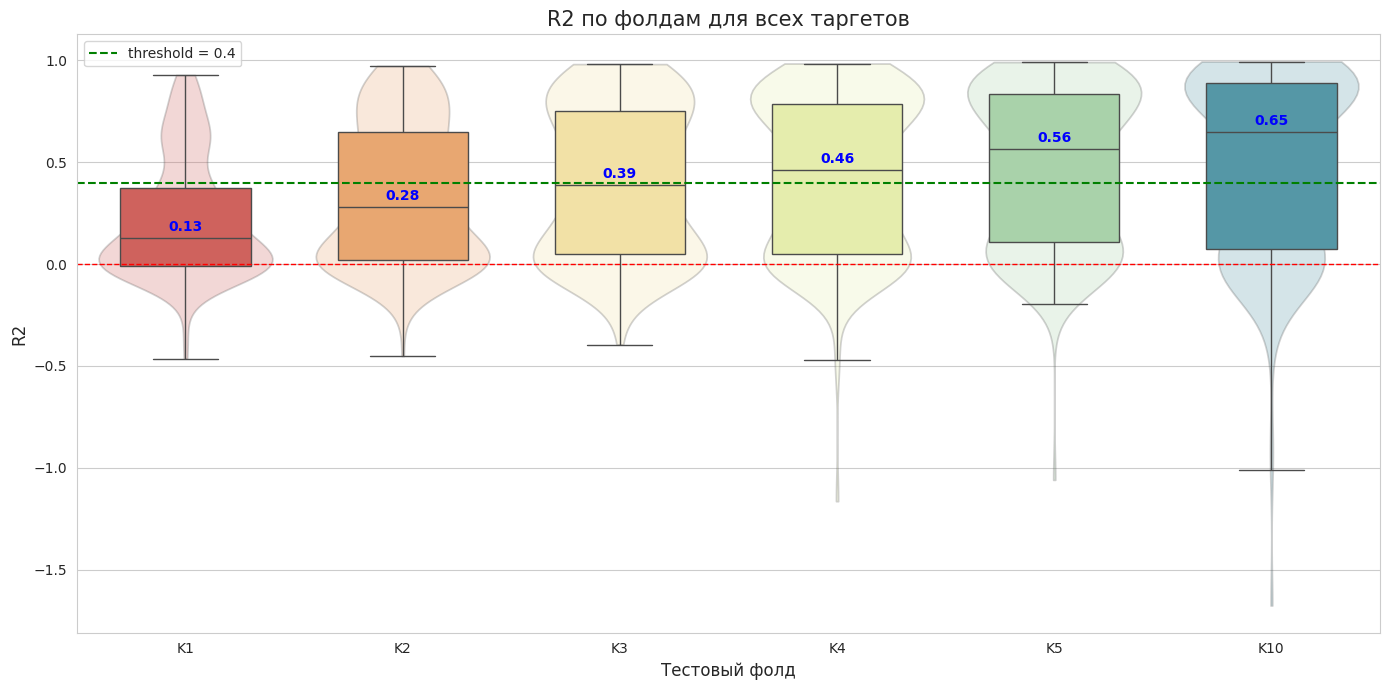


Median R2 by fold:
fold
K1     0.128304
K2     0.280569
K3     0.387645
K4     0.461076
K5     0.563250
K10    0.649936
Name: R2, dtype: float64


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Берем уже агрегированные метрики по target/fold.
# Если переменная metrics_df есть в памяти - используем ее, иначе читаем из файла.
if 'metrics_df' in globals():
    df_plot = metrics_df.copy()
else:
    df_plot = pd.read_csv(OUTPUT_DIR / 'detailed_metrics.csv')

df_plot['k_num'] = df_plot['fold'].str.extract(r'(\d+)').astype(int)
df_plot = df_plot.sort_values('k_num')
fold_order = [f'K{i}' for i in sorted(df_plot['k_num'].unique())]

plt.figure(figsize=(14, 7))
sns.set_style('whitegrid')

sns.boxplot(
    data=df_plot,
    x='fold',
    y='R2',
    order=fold_order,
    palette='Spectral',
    showfliers=False,
    width=0.6,
)

sns.violinplot(
    data=df_plot,
    x='fold',
    y='R2',
    order=fold_order,
    palette='Spectral',
    inner=None,
    cut=0,
    alpha=0.25,
)

plt.title('R2 по фолдам для всех таргетов', fontsize=15)
plt.xlabel('Тестовый фолд', fontsize=12)
plt.ylabel('R2', fontsize=12)
plt.axhline(0.4, color='green', linestyle='--', linewidth=1.5, label='threshold = 0.4')
plt.axhline(0, color='red', linestyle='--', linewidth=1.0)

medians = df_plot.groupby('fold')['R2'].median().reindex(fold_order)
for i, val in enumerate(medians):
    plt.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontweight='bold', color='blue')

plt.legend()
plt.tight_layout()
plt.show()

print('\nMedian R2 by fold:')
print(medians)

/tmp/ipykernel_18/1759998581.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_18/1759998581.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


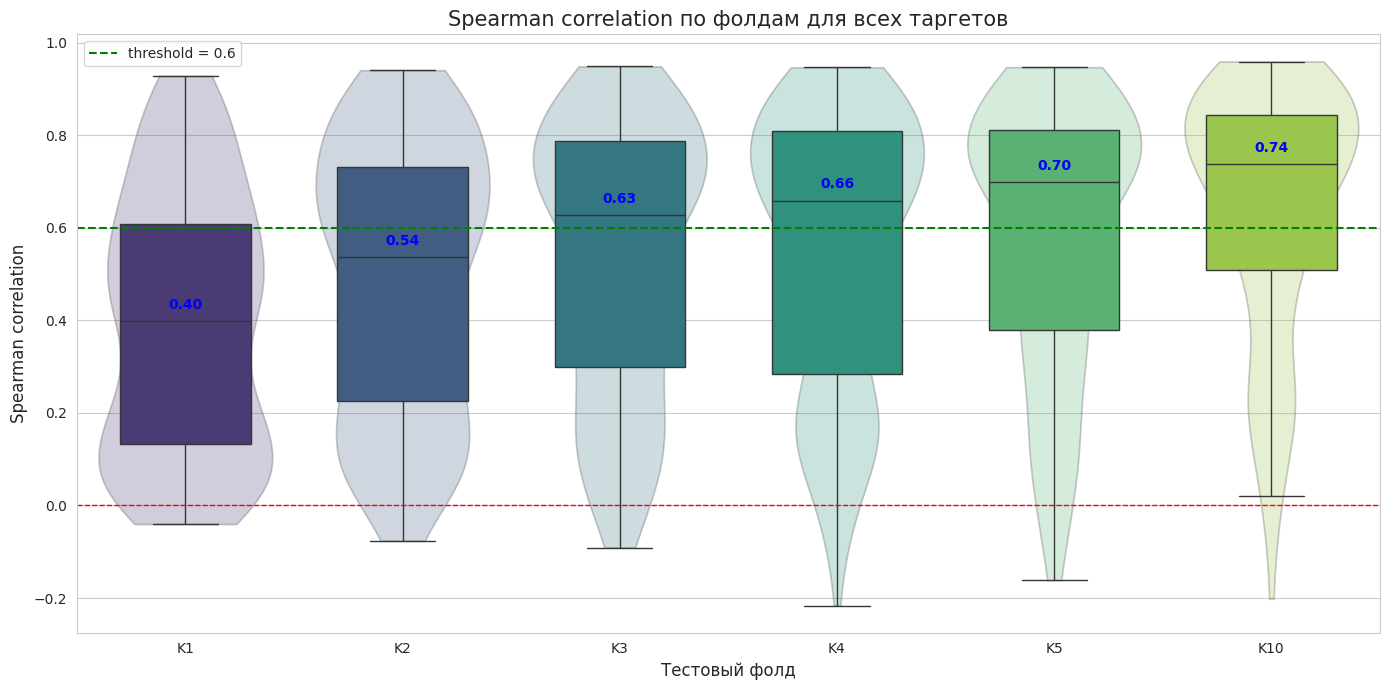


Median Spearman by fold:
fold
K1     0.398053
K2     0.536180
K3     0.627710
K4     0.658602
K5     0.699091
K10    0.737660
Name: Spearman, dtype: float64


In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

if 'metrics_df' in globals():
    df_plot = metrics_df.copy()
else:
    df_plot = pd.read_csv(OUTPUT_DIR / 'detailed_metrics.csv')

df_plot['k_num'] = df_plot['fold'].str.extract(r'(\d+)').astype(int)
df_plot = df_plot.sort_values('k_num')
fold_order = [f'K{i}' for i in sorted(df_plot['k_num'].unique())]

plt.figure(figsize=(14, 7))
sns.set_style('whitegrid')

sns.boxplot(
    data=df_plot,
    x='fold',
    y='Spearman',
    order=fold_order,
    palette='viridis',
    showfliers=False,
    width=0.6,
)

sns.violinplot(
    data=df_plot,
    x='fold',
    y='Spearman',
    order=fold_order,
    palette='viridis',
    inner=None,
    cut=0,
    alpha=0.25,
)

plt.title('Spearman correlation по фолдам для всех таргетов', fontsize=15)
plt.xlabel('Тестовый фолд', fontsize=12)
plt.ylabel('Spearman correlation', fontsize=12)
plt.axhline(0.6, color='green', linestyle='--', linewidth=1.5, label='threshold = 0.6')
plt.axhline(0, color='red', linestyle='--', linewidth=1.0)

medians = df_plot.groupby('fold')['Spearman'].median().reindex(fold_order)
for i, val in enumerate(medians):
    if pd.notna(val):
        plt.text(i, val + 0.02, f'{val:.2f}', ha='center', va='bottom', fontweight='bold', color='blue')

plt.legend()
plt.tight_layout()
plt.show()

print('\nMedian Spearman by fold:')
print(medians)

In [5]:
# Считаем, сколько таргетов не достигли порогов по средним метрикам по фолдам.
# Логика: таргет считается "прошедшим", если у него есть хотя бы одна из метрик:
# mean R2 >= 0.4 ИЛИ mean Spearman >= 0.6.

if 'summary_df' in globals():
    df_summary = summary_df.copy()
else:
    df_summary = pd.read_csv(OUTPUT_DIR / 'summary_metrics.csv')

THRESH_R2 = 0.4
THRESH_SPEARMAN = 0.6

failed_mask = (df_summary['R2'] < THRESH_R2) & (df_summary['Spearman'] < THRESH_SPEARMAN)
failed_targets_df = df_summary.loc[failed_mask].copy()
passed_targets_df = df_summary.loc[~failed_mask].copy()

print(f'Total targets: {len(df_summary)}')
print(f'Passed (R2 >= {THRESH_R2} or Spearman >= {THRESH_SPEARMAN}): {len(passed_targets_df)}')
print(f'Failed both thresholds: {len(failed_targets_df)}')

failed_targets_df = failed_targets_df.sort_values(['stage', 'R2', 'Spearman'])
failed_targets_df.head(20)

Total targets: 236
Passed (R2 >= 0.4 or Spearman >= 0.6): 127
Failed both thresholds: 109


,stage,miRNA,R2,Spearman,MSE,n_features_used,n_missing_features
99,stage_4,hsa-mir-182,0.385946,0.585572,0.075116,738.0,0.0
127,stage_5,hsa-mir-33a,0.266536,0.572085,4.841804,492.0,0.0
129,stage_5,hsa-mir-7-1,0.320390,0.598491,3.845141,444.0,0.0
125,stage_5,hsa-mir-19b-1,0.330607,0.531397,9.416184,492.0,0.0
128,stage_5,hsa-mir-585,0.342655,0.540490,6.531135,248.0,0.0
123,stage_5,hsa-mir-127,0.377751,0.468802,2.733652,560.0,0.0
133,stage_6,hsa-mir-301b,0.125766,0.477993,12.146001,381.0,0.0
134,stage_6,hsa-mir-30e,0.317806,0.565211,0.090922,481.0,0.0
132,stage_6,hsa-mir-29b-1,0.333395,0.542284,6.722966,628.0,0.0
130,stage_6,hsa-mir-129-2,0.346750,0.502740,9.104983,526.0,0.0


In [23]:
df_res = pd.read_csv('test_inference_v3_gpu_fast/detailed_metrics.csv')

In [24]:
stage_1_K1 = df_res[df_res['stage'] == 'stage_1'][df_res[df_res['stage'] == 'stage_1']['fold'] == 'K1']

In [31]:
good_ones = stage_1_K1[stage_1_K1['R2'] > 0.4]['miRNA'].tolist()

In [33]:
with open('good_ones.txt', 'w') as file:
    for mir in good_ones:
        file.write(f'{mir}\n')

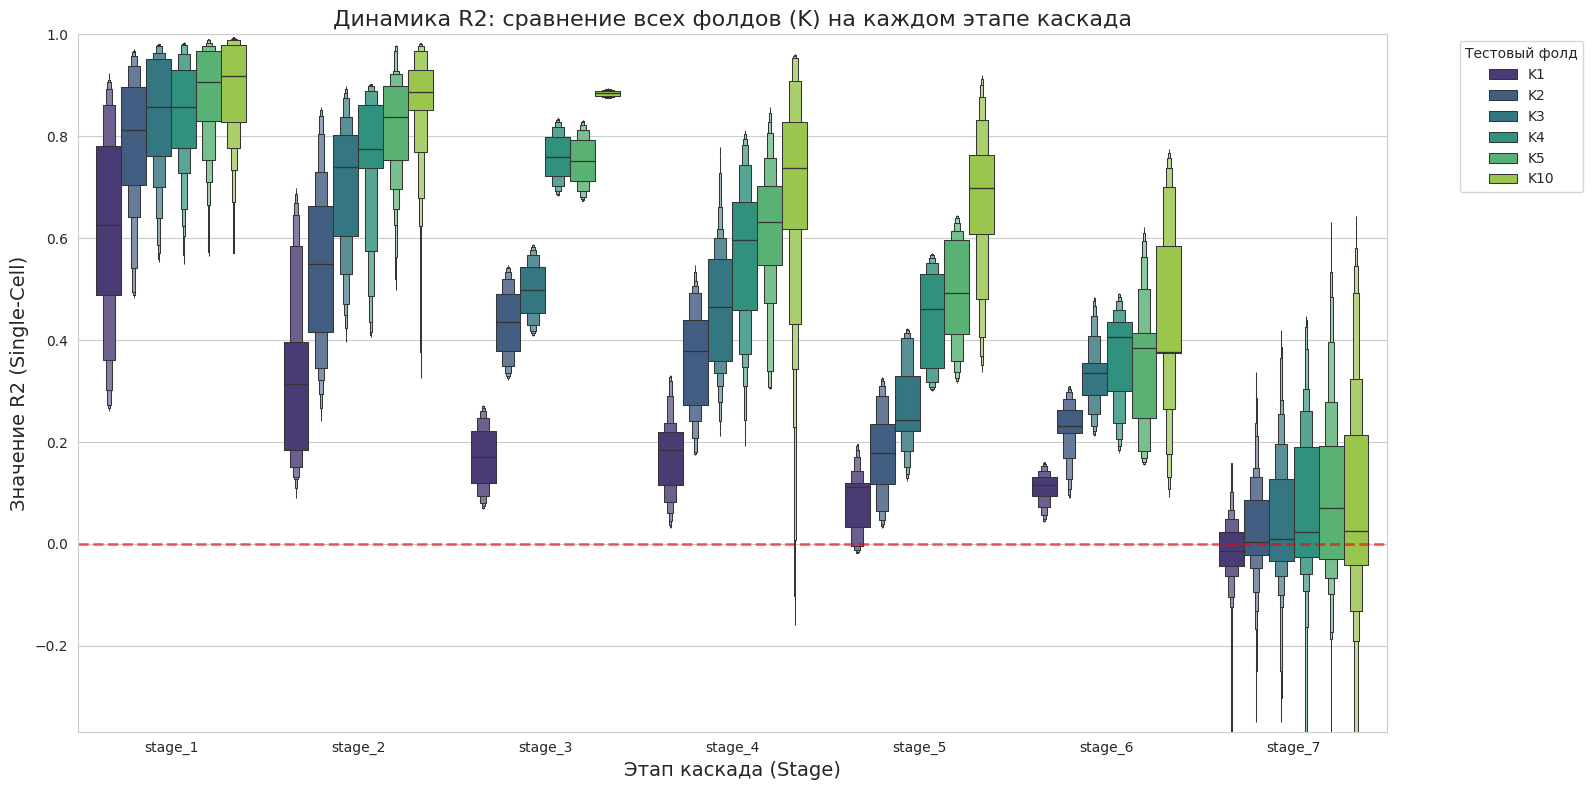


МЕДИАННЫЙ R2 ПО ЭТАПАМ И ФОЛДАМ:
fold           K1        K2        K3        K4        K5       K10
stage                                                              
stage_1  0.624969  0.812053  0.857462  0.857815  0.907133  0.918934
stage_2  0.312903  0.548847  0.739509  0.775176  0.837150  0.887387
stage_3  0.170565  0.434654  0.498141  0.759843  0.751881  0.884011
stage_4  0.184204  0.378945  0.465278  0.597065  0.631260  0.737334
stage_5  0.111994  0.177929  0.242946  0.461698  0.492745  0.698321
stage_6  0.114986  0.232341  0.335023  0.405688  0.384266  0.377128
stage_7 -0.013295  0.002931  0.010639  0.023857  0.071212  0.025801

График сохранен: /home/amismailov/project/test_inference_v3_gpu_fast/R2_progression_stages_K.png


In [34]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Берем детальные метрики из памяти или из сохраненного CSV
if 'metrics_df' in globals():
    df_plot = metrics_df.copy()
else:
    df_plot = pd.read_csv(OUTPUT_DIR / 'detailed_metrics.csv')

# Правильная сортировка этапов (1 -> 7) и фолдов (1 -> 10)
df_plot['stage_num'] = df_plot['stage'].str.extract(r'(\d+)').astype(int)
df_plot['k_num'] = df_plot['fold'].str.extract(r'(\d+)').astype(int)
df_plot = df_plot.sort_values(['stage_num', 'k_num'])

stage_order = [f'stage_{i}' for i in sorted(df_plot['stage_num'].unique())]
fold_order = [f'K{i}' for i in sorted(df_plot['k_num'].unique())]

plt.figure(figsize=(16, 8))
sns.set_style('whitegrid')

sns.boxenplot(
    data=df_plot,
    x='stage',
    y='R2',
    hue='fold',
    order=stage_order,
    hue_order=fold_order,
    palette='viridis',
    k_depth='proportion',
    showfliers=False,
)

plt.title('Динамика R2: сравнение всех фолдов (K) на каждом этапе каскада', fontsize=16)
plt.xlabel('Этап каскада (Stage)', fontsize=14)
plt.ylabel('Значение R2 (Single-Cell)', fontsize=14)
plt.legend(title='Тестовый фолд', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.axhline(0, color='red', linestyle='--', alpha=0.6, linewidth=2)
plt.ylim(df_plot['R2'].quantile(0.01) - 0.1, 1.0)
plt.tight_layout()

plot_path = OUTPUT_DIR / 'R2_progression_stages_K.png'
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()

pivot_medians = df_plot.pivot_table(
    index='stage',
    columns='fold',
    values='R2',
    aggfunc='median',
)

ordered_cols = [col for col in fold_order if col in pivot_medians.columns]
print('\nМЕДИАННЫЙ R2 ПО ЭТАПАМ И ФОЛДАМ:')
print(pivot_medians[ordered_cols].to_string())
print(f'\nГрафик сохранен: {plot_path}')


In [1]:
import pandas as pd

In [19]:
bulk = pd.read_parquet('TEST/Y_K1.parquet')

In [20]:
bulk

,boot_K1_293T-MS_0,boot_K1_293T-MS_1,boot_K1_293T-MS_2,boot_K1_293T-MS_3,boot_K1_293T-MS_4,boot_K1_293T-MS_5,boot_K1_293T-MS_6,boot_K1_293T-MS_7,boot_K1_293T-MS_8,boot_K1_293T-MS_9,...,boot_K1_K562-MS_490,boot_K1_K562-MS_491,boot_K1_K562-MS_492,boot_K1_K562-MS_493,boot_K1_K562-MS_494,boot_K1_K562-MS_495,boot_K1_K562-MS_496,boot_K1_K562-MS_497,boot_K1_K562-MS_498,boot_K1_K562-MS_499
hsa-let-7a-2,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7b,0.000000,0.000000,9.544408,0.000000,0.000000,0.000000,0.000000,0.000000,9.762054,0.000000,...,0.000000,0.000000,0.00000,0.000000,8.726135,0.000000,0.000000,8.245459,0.000000,0.000000
hsa-let-7c,9.203547,0.000000,9.544408,0.000000,9.906549,9.768317,0.000000,0.000000,9.762054,0.000000,...,0.000000,8.795906,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-let-7d,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,8.245459,0.000000,0.000000
hsa-let-7e,12.201405,10.597110,9.544408,11.876670,11.905421,9.768317,11.527980,11.371780,11.760808,0.000000,...,10.330455,10.378703,0.00000,0.000000,9.724431,8.766839,8.708008,11.241294,10.530243,10.525280
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
hsa-mir-95,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-mir-96,10.786878,10.012613,0.000000,10.877053,0.000000,10.767490,9.529445,9.373413,0.000000,10.273631,...,11.789173,11.378161,11.20937,11.026873,9.724431,10.764353,10.705419,11.241294,11.529755,11.524791
hsa-mir-98,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,10.20998,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
hsa-mir-99a,0.000000,9.014009,0.000000,0.000000,9.906549,0.000000,9.529445,9.373413,0.000000,0.000000,...,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
